# Floodscan timing
<!-- markdownlint-disable MD013 -->
Checking timing of Floodscan in N'Djamena and Mayo-Kebbi Est vs observational and GloFAS reanalysis at N'Djamena station.

In [1]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

In [123]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import ocha_stratus as stratus
import pandas as pd

from src.datasources import glofas, dre
from src.constants import *

In [55]:
df_dre = dre.open_dre_obsv(from_blob=True)

/Users/tdowning/OCHA/repos/pa-aa-tcd-flooding/src/datasources/dre.py:22: FutureWarning: Passing bytes to 'read_excel' is deprecated and will be removed in a future version. To read from a byte string, wrap it in a `BytesIO` object.
  df = pd.read_excel(filepath, sheet_name="Sheet1", skiprows=1)


In [98]:
# exclude past 2023 because timing seems off
df_dre = df_dre[df_dre["Date"].dt.year < 2023]

In [44]:
names = {NDJAMENA1: "N'Djamena", MAYOKEBBIEST1: "Mayo-Kebbi Est"}

In [65]:
query = f"""
SELECT pcode, valid_date, mean
FROM public.floodscan
WHERE pcode IN {(NDJAMENA1, MAYOKEBBIEST1)}
AND band = 'SFED'
"""
df_fs = pd.read_sql(
    query, stratus.get_engine(stage="prod"), parse_dates=["valid_date"]
)
df_fs["name"] = df_fs["pcode"].replace(names)

In [66]:
df_fs

,pcode,valid_date,mean,name
0,TD11,2023-03-29,0.000000,Mayo-Kebbi Est
1,TD18,2023-03-29,0.000000,N'Djamena
2,TD11,2023-03-30,0.000000,Mayo-Kebbi Est
3,TD18,2023-03-30,0.000000,N'Djamena
4,TD11,2023-03-31,0.000000,Mayo-Kebbi Est
...,...,...,...,...
20117,TD18,2011-12-27,0.000247,N'Djamena
20118,TD11,2011-12-28,0.000000,Mayo-Kebbi Est
20119,TD18,2011-12-28,0.000627,N'Djamena
20120,TD11,2011-12-31,0.000000,Mayo-Kebbi Est


In [38]:
df_gf = glofas.load_glofas_reanalysis(station_name="ndjamena")

In [39]:
df_gf

,time,dis24
0,1979-01-01,454.390625
1,1979-01-02,448.234375
2,1979-01-03,442.218750
3,1979-01-04,436.328125
4,1979-01-05,430.562500
...,...,...
16797,2024-12-27,180.539062
16798,2024-12-28,176.726562
16799,2024-12-29,173.054688
16800,2024-12-30,169.460938


In [99]:
df_daily = (
    df_fs.pivot(columns="name", index="valid_date", values="mean")
    .reset_index()
    .merge(df_gf.rename(columns={"time": "valid_date"}))
    .merge(df_dre.rename(columns={"Date": "valid_date"}), how="left")
)

In [100]:
df_daily

,valid_date,Mayo-Kebbi Est,N'Djamena,dis24,level_cm
0,1998-01-12,0.0,0.000606,507.703125,175.0
1,1998-01-12,0.0,0.000606,507.703125,175.0
2,1998-01-12,0.0,0.000606,507.703125,175.0
3,1998-01-13,0.0,0.000606,504.046875,174.0
4,1998-01-13,0.0,0.000606,504.046875,174.0
...,...,...,...,...,...
19574,2024-12-27,0.0,0.019716,180.539062,NaN
19575,2024-12-28,0.0,0.017319,176.726562,NaN
19576,2024-12-29,0.0,0.015209,173.054688,NaN
19577,2024-12-30,0.0,0.014652,169.460938,NaN


In [101]:
for col in df_daily:
    if col == "valid_date":
        continue
    df_daily[f"{col}_rel"] = df_daily[col] / df_daily[col].max()

In [102]:
df_daily

,valid_date,Mayo-Kebbi Est,N'Djamena,dis24,level_cm,Mayo-Kebbi Est_rel,N'Djamena_rel,dis24_rel,level_cm_rel
0,1998-01-12,0.0,0.000606,507.703125,175.0,0.0,0.001806,0.059875,0.214988
1,1998-01-12,0.0,0.000606,507.703125,175.0,0.0,0.001806,0.059875,0.214988
2,1998-01-12,0.0,0.000606,507.703125,175.0,0.0,0.001806,0.059875,0.214988
3,1998-01-13,0.0,0.000606,504.046875,174.0,0.0,0.001806,0.059444,0.213759
4,1998-01-13,0.0,0.000606,504.046875,174.0,0.0,0.001806,0.059444,0.213759
...,...,...,...,...,...,...,...,...,...
19574,2024-12-27,0.0,0.019716,180.539062,NaN,0.0,0.058737,0.021292,NaN
19575,2024-12-28,0.0,0.017319,176.726562,NaN,0.0,0.051595,0.020842,NaN
19576,2024-12-29,0.0,0.015209,173.054688,NaN,0.0,0.045311,0.020409,NaN
19577,2024-12-30,0.0,0.014652,169.460938,NaN,0.0,0.043650,0.019985,NaN


/var/folders/66/764yc5p92nvdc_nm3xmy5rn40000gn/T/ipykernel_15914/3622497210.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


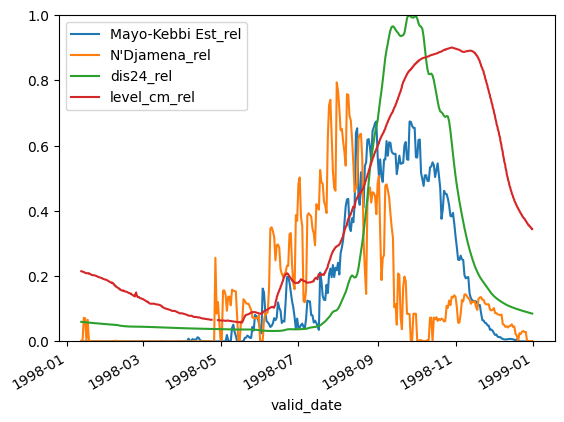

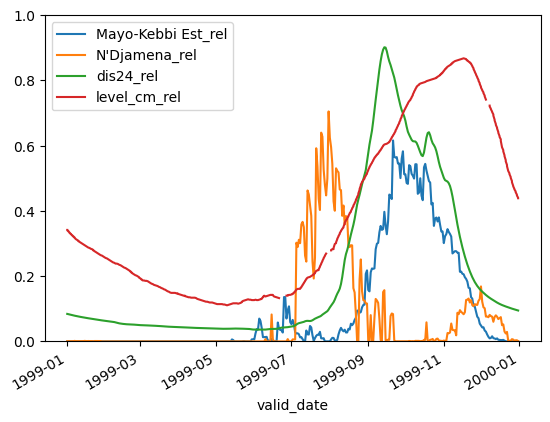

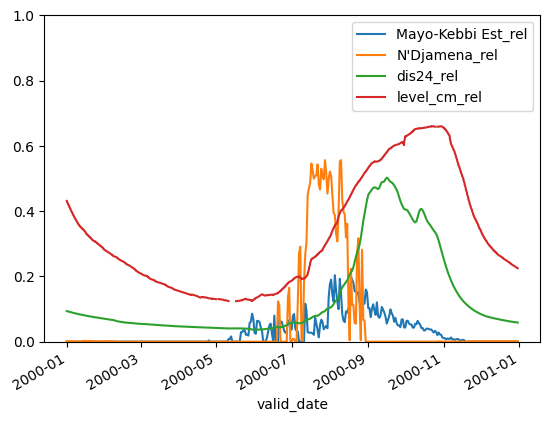

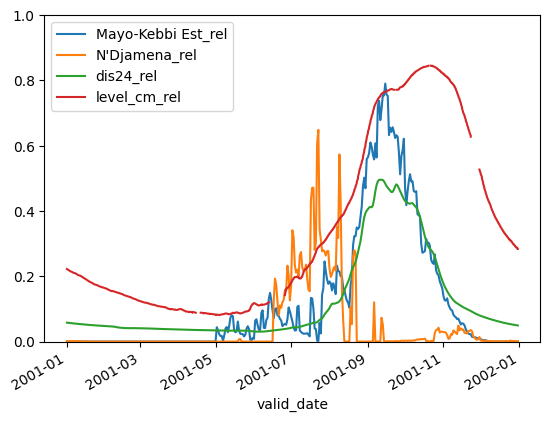

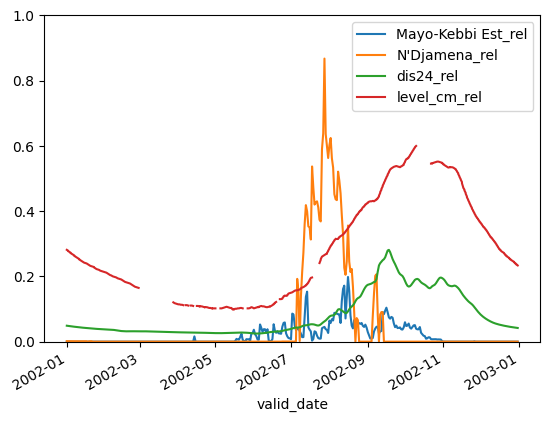

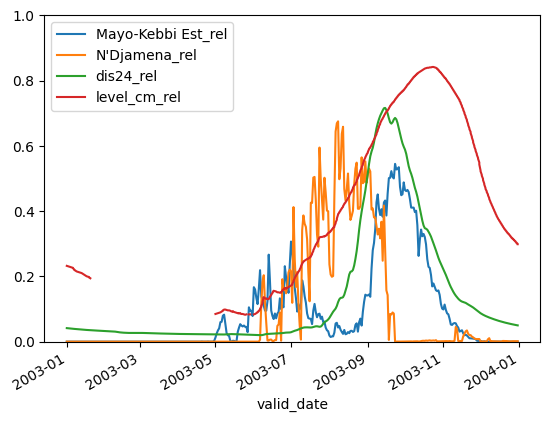

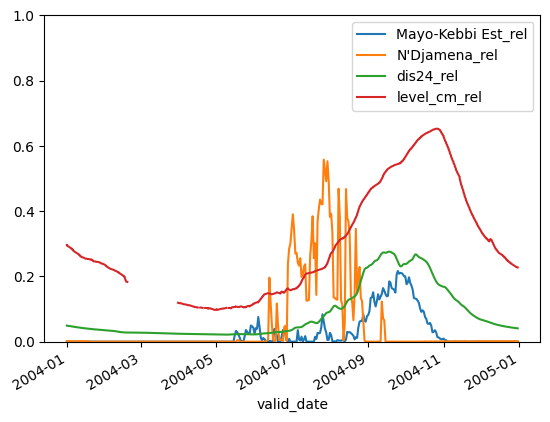

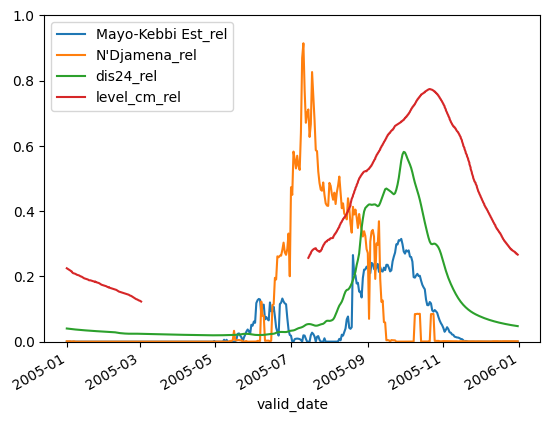

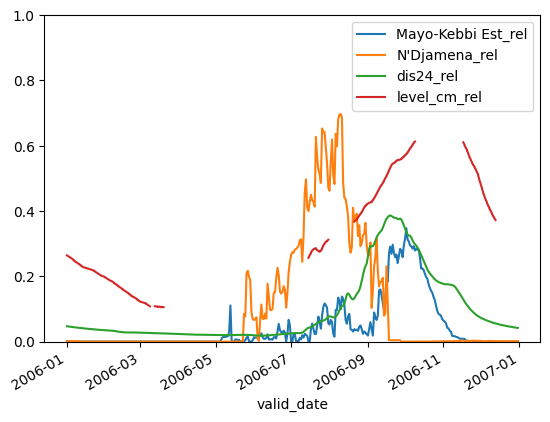

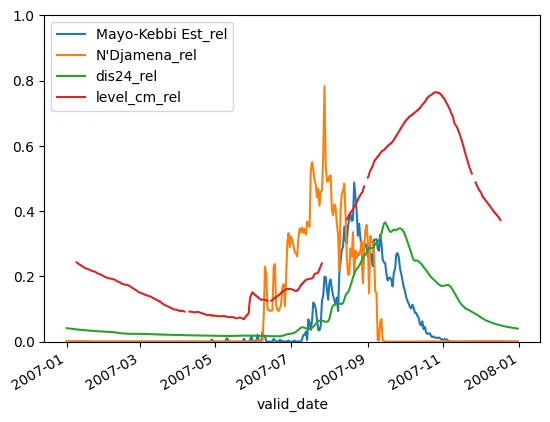

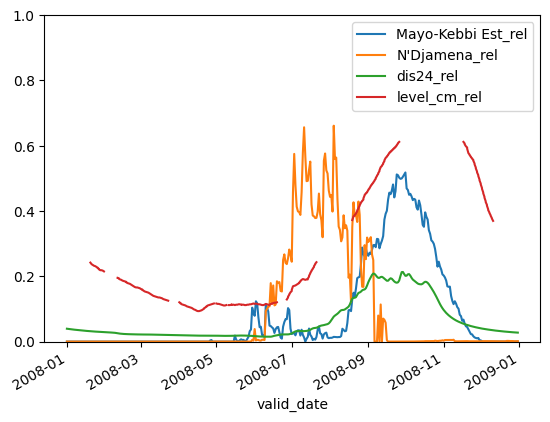

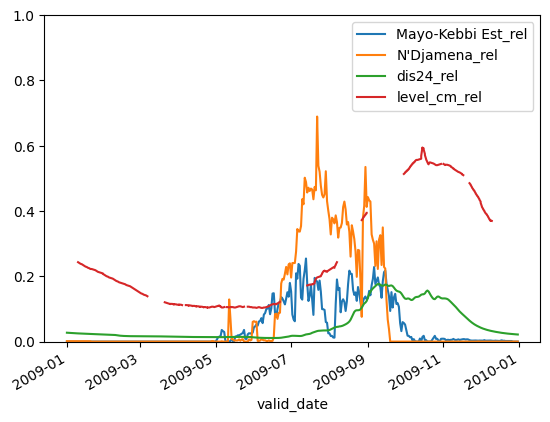

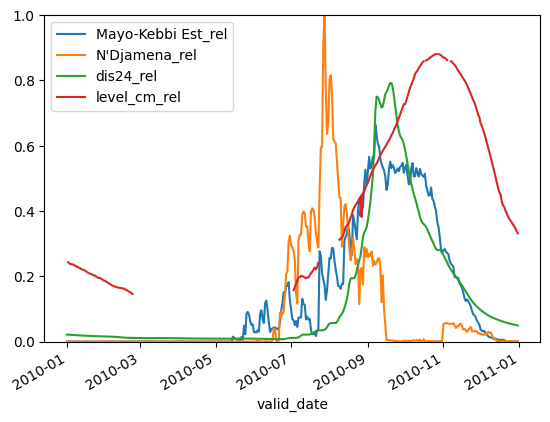

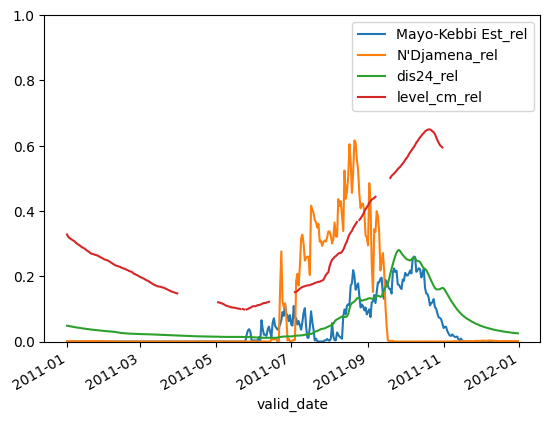

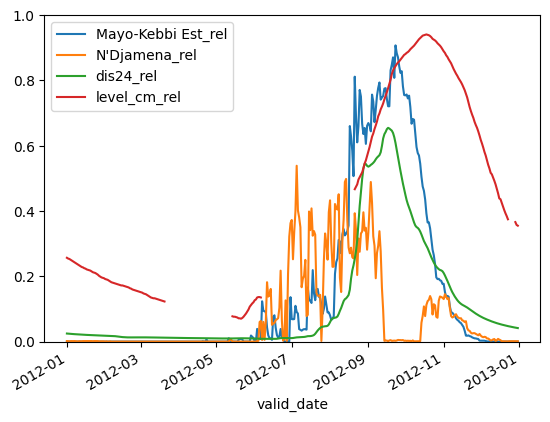

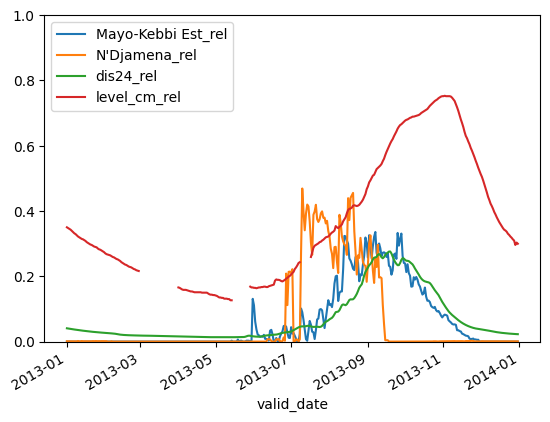

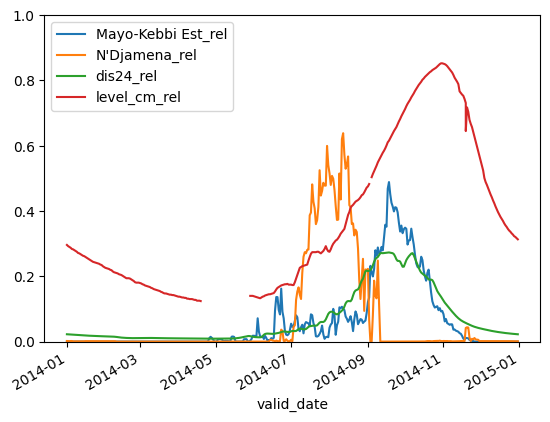

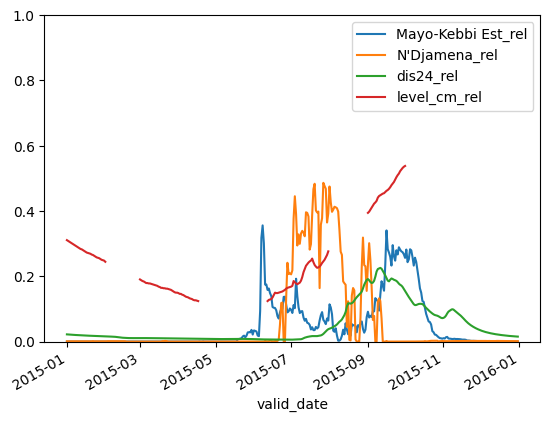

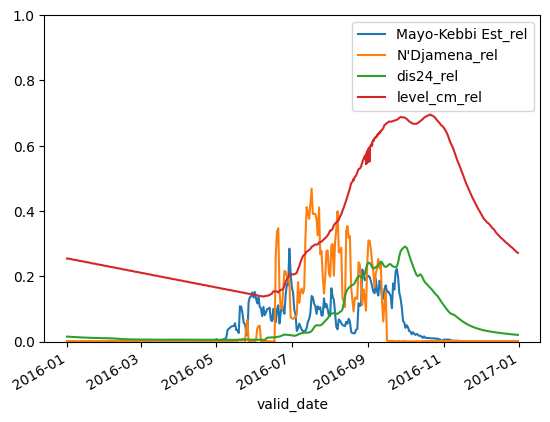

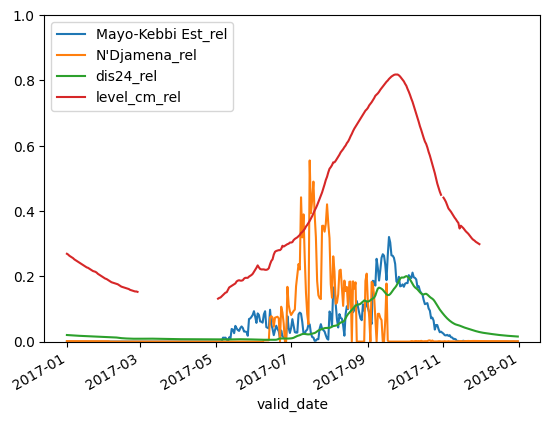

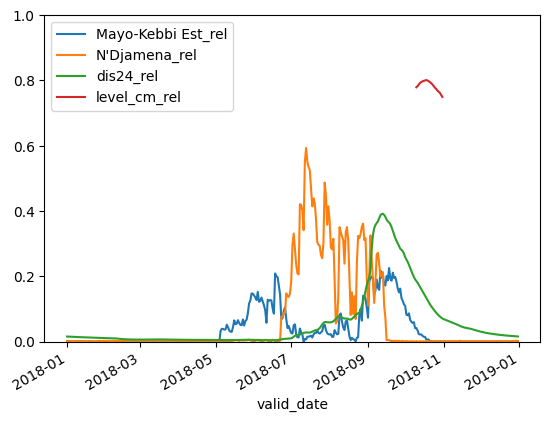

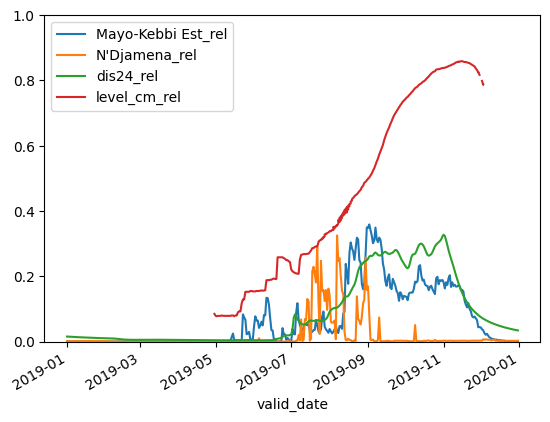

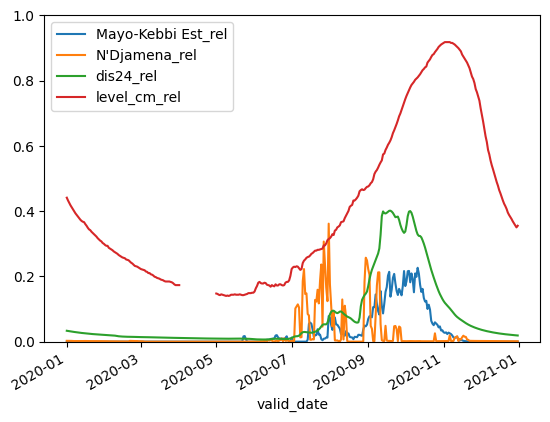

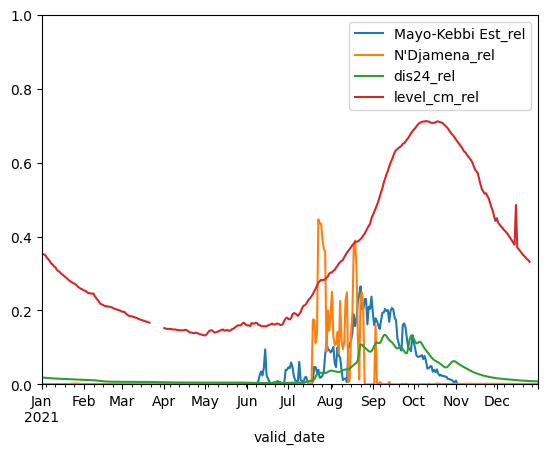

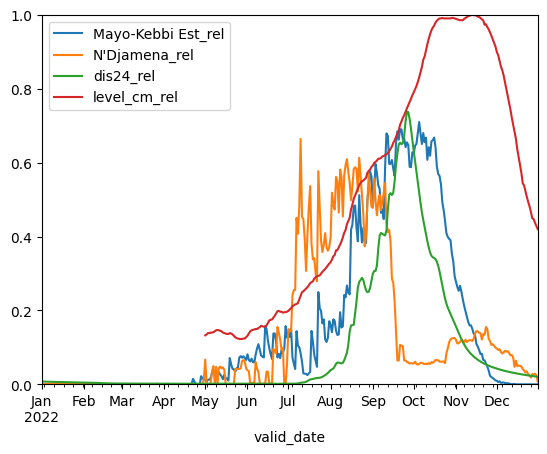

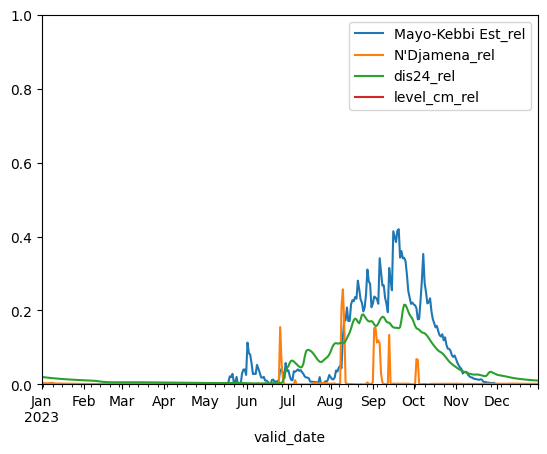

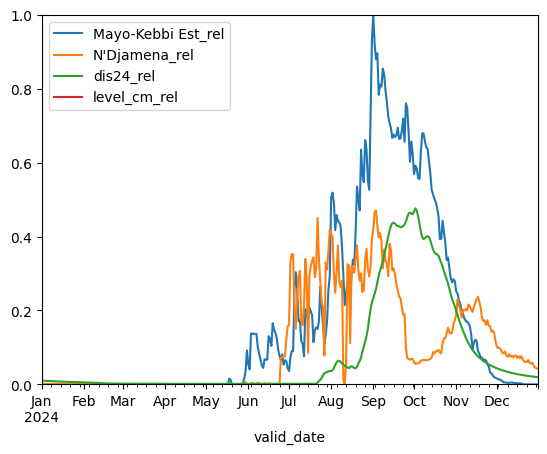

In [103]:
for year, group in df_daily.groupby(df_daily["valid_date"].dt.year):
    fig, ax = plt.subplots()
    group.set_index("valid_date")[[x for x in group if "rel" in x]].plot(ax=ax)
    ax.set_ylim((0, 1))

In [104]:
df_daily["plot_date"] = df_daily["valid_date"].map(
    lambda x: pd.Timestamp(
        year=1904,
        month=x.month,
        day=x.day,
    )
)

In [105]:
df_daily_mean = (
    df_daily.groupby(df_daily["plot_date"])[
        [x for x in df_daily if "rel" in x]
    ]
    .mean()
    .reset_index()
)

In [106]:
df_daily_mean

,plot_date,Mayo-Kebbi Est_rel,N'Djamena_rel,dis24_rel,level_cm_rel
0,1904-01-01,0.000000e+00,0.001190,0.040638,0.297795
1,1904-01-02,0.000000e+00,0.001146,0.039759,0.292048
2,1904-01-03,0.000000e+00,0.001038,0.039262,0.288809
3,1904-01-04,0.000000e+00,0.001122,0.038779,0.285822
4,1904-01-05,0.000000e+00,0.001032,0.038312,0.282751
...,...,...,...,...,...
361,1904-12-27,2.486885e-07,0.003046,0.042776,0.318613
362,1904-12-28,0.000000e+00,0.002624,0.042191,0.314364
363,1904-12-29,0.000000e+00,0.002609,0.041649,0.312134
364,1904-12-30,0.000000e+00,0.002501,0.041100,0.307598


In [126]:
rel_cols

['Mayo-Kebbi Est_rel', "N'Djamena_rel", 'dis24_rel', 'level_cm_rel']

In [136]:
labels = {
    "dis24_rel": "GloFAS reanalysis",
    "level_cm_rel": "Observed river level",
}

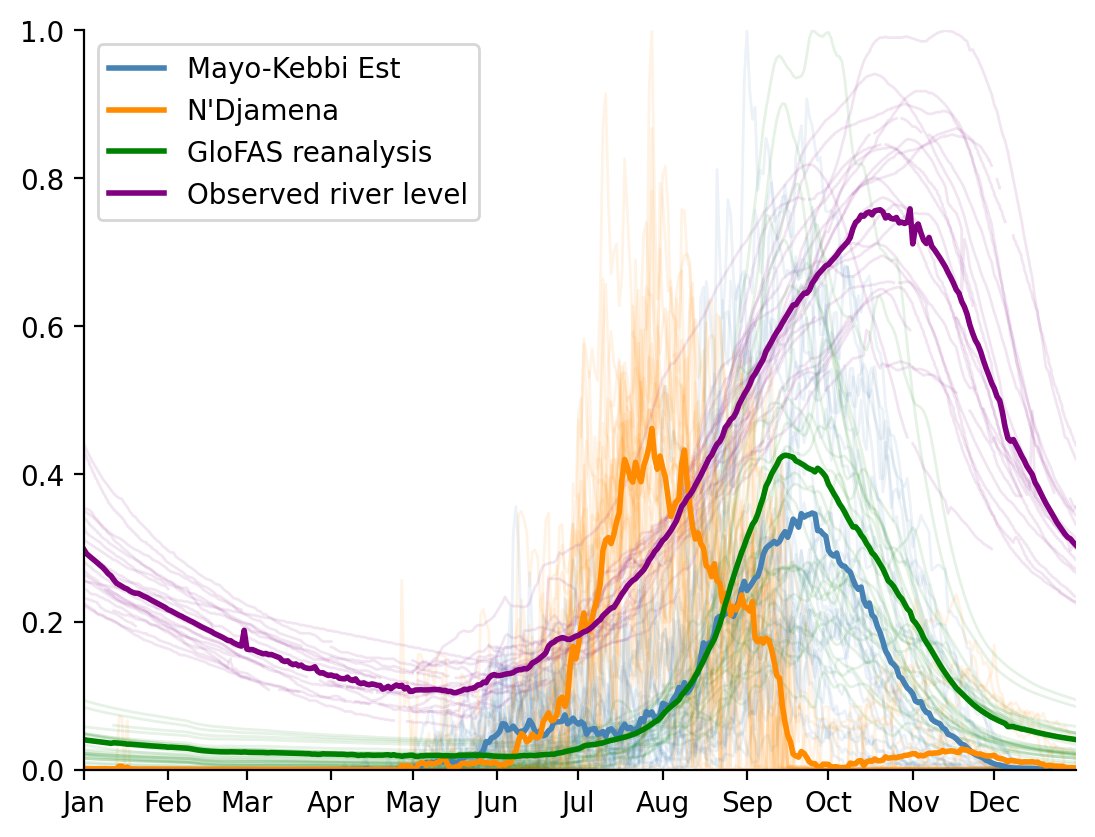

In [137]:
colors = ["steelblue", "darkorange", "green", "purple"]

# Get the list of columns to plot (assumes order is consistent)
rel_cols = [col for col in df_daily.columns if "rel" in col]

# Map columns to colors by position
col_colors = dict(zip(rel_cols, colors))

fig, ax = plt.subplots(dpi=200)

for year, group in df_daily.groupby(df_daily["valid_date"].dt.year):
    group = group.set_index("plot_date")
    for col in rel_cols:
        ax.plot(
            group.index,
            group[col],
            color=col_colors[col],
            linewidth=1,
            alpha=0.1,
        )
for col in rel_cols:
    ax.plot(
        df_daily_mean["plot_date"],
        df_daily_mean[col],
        color=col_colors[col],
        linewidth=2,
        label=labels.get(col, col).removesuffix("_rel"),
    )

ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

ax.set_ylim((0, 1))
ax.set_xlim(
    (df_daily_mean["plot_date"].min(), df_daily_mean["plot_date"].max())
)

[ax.spines[x].set_visible(False) for x in ["top", "right"]]
ax.legend()

To answer the question about timing, here is a plot that shows:

- purple: Mayo-Kebbi Est (new province) Floodscan extent
- orange: N'Djamena (old province) Floodscan extent
- green: GloFAS reanalysis (N'Djamena station)
- purple: observed river level (N'Djamena station)

The plot shows all years since 1998 as fine lines, and the day-wise mean as the bold line.
We can see a few things:

1. The river has pretty much a single big peak each year
2. GloFAS gets the shape roughly right, but about a month early
3. Mayo-Kebbi Est flood extent matches the GloFAS reanalysis nicely
    - I suspect this is because it's upstream of N'Djamena, so this kind of "cancels out" the hydrological model miscalibration
    - I'll get the average timings to put in the framework, so people know that we don't get the extra 30-ish days leadtime in the new province
4. The elephant in the room- the N'Djamena flood extent has a bunch of big peaks earlier in the year, way before the river level peaks.
    - We already knew this, since this went into the framework last year
    - If you look closely, there are some peaks in Oct-Nov. Based on previous analysis, these align with riverine flooding years. So, something about Floodscan's bias (and low resolution) means that we barely pick up on this, but we do pick up one the earlier peaks (from flash flooding? or something else).